In [1]:
import cv2
from pathlib import Path
import pandas as pd
import numpy as np
from skimage.draw import polygon
import matplotlib.pyplot as plt
import sys
from scipy import stats as scipy_stats

In [2]:
# now for ejection fraction
# path_ef_ens = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/ensemble/results_ensemble_ef_adults.csv'
# path_ef_phiseg = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/phiseg/results_phiseg_ef_adults.csv'
# path_ef_vids = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/vids/results_vids_ef_adults_3.csv'

# combined normal
path_ef_ens = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/ens_comb/results_ensemble_ef_adults_norm.csv'
path_ef_phiseg = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/phiseg_comb/results_phiseg_ef_norm.csv'
path_ef_vids = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/vids_comb/results_vids_ef_norm.csv'

# combined augmentation
# path_ef_ens = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/ens_comb/results_ensemble_ef_adults_aug.csv'
# path_ef_phiseg = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/phiseg_comb/results_phiseg_ef_augm.csv'
# path_ef_vids = '/home/paul/workspace/year1/projects/ped_unc/echonet/exp/results_data/vids_comb/results_vids_ef_augm.csv'

df_ef_ens = pd.read_csv(path_ef_ens)
df_ef_phiseg = pd.read_csv(path_ef_phiseg)
df_ef_vids = pd.read_csv(path_ef_vids)

In [3]:
bins = [-np.inf, 0, 2, 5, 12, 18]
labels = ['infant', 'toddler', 'preschooler', 'school age', 'teenager']

# bins = [-np.inf, 12, 18]
# labels = ['children', 'teenager']

df_ef_ens['age_group'] = pd.cut(df_ef_ens['age'], bins=bins, labels=labels, right=True)

# Absolute error
df_ef_ens['abs_error'] = np.abs(df_ef_ens['mean_ef_pred'] - df_ef_ens['gt_ef'])

# Uncertainty interval: [mean_ef_pred - std_ef_pred, mean_ef_pred + std_ef_pred]
# Coverage: does gt_ef fall inside this interval?
df_ef_ens['covered'] = (
    (df_ef_ens['gt_ef'] >= df_ef_ens['mean_ef_pred'] - df_ef_ens['std_ef_pred']) &
    (df_ef_ens['gt_ef'] <= df_ef_ens['mean_ef_pred'] + df_ef_ens['std_ef_pred'])
)

# Interval size = 2 * std_ef_pred
df_ef_ens['interval_size'] = 2 * df_ef_ens['std_ef_pred']


df_ef_phiseg['age_group'] = pd.cut(df_ef_phiseg['age'], bins=bins, labels=labels, right=True)

# Absolute error
df_ef_phiseg['abs_error'] = np.abs(df_ef_phiseg['mean_ef_pred'] - df_ef_phiseg['gt_ef'])

# Uncertainty interval: [mean_ef_pred - std_ef_pred, mean_ef_pred + std_ef_pred]
# Coverage: does gt_ef fall inside this interval?
df_ef_phiseg['covered'] = (
    (df_ef_phiseg['gt_ef'] >= df_ef_phiseg['mean_ef_pred'] - df_ef_phiseg['std_ef_pred']) &
    (df_ef_phiseg['gt_ef'] <= df_ef_phiseg['mean_ef_pred'] + df_ef_phiseg['std_ef_pred'])
)

# Interval size = 2 * std_ef_pred
df_ef_phiseg['interval_size'] = 2 * df_ef_phiseg['std_ef_pred']


df_ef_vids['age_group'] = pd.cut(df_ef_vids['age'], bins=bins, labels=labels, right=True)

# Absolute error
df_ef_vids['abs_error'] = np.abs(df_ef_vids['mean_ef_pred'] - df_ef_vids['gt_ef'])

# Uncertainty interval: [mean_ef_pred - std_ef_pred, mean_ef_pred + std_ef_pred]
# Coverage: does gt_ef fall inside this interval?
df_ef_vids['covered'] = (
    (df_ef_vids['gt_ef'] >= df_ef_vids['mean_ef_pred'] - df_ef_vids['std_ef_pred']) &
    (df_ef_vids['gt_ef'] <= df_ef_vids['mean_ef_pred'] + df_ef_vids['std_ef_pred'])
)

# Interval size = 2 * std_ef_pred
df_ef_vids['interval_size'] = 2 * df_ef_vids['std_ef_pred']

In [4]:
df_ef_vids.head()

,filename,age,mean_ef_pred,std_ef_pred,gt_ef,n_valid_pairs,n_total_pairs,ed_fail_rate,es_fail_rate,status,age_group,abs_error,covered,interval_size
0,CR32a7581-CR32a9b0b-000051.h5,18,43.699337,2.700858,44.31,20,20,0.0,0.0,valid,teenager,0.610663,True,5.401716
1,CR32a9679-CR3dcb61c-000048.h5,18,50.658515,4.760477,68.16,20,20,0.0,0.0,valid,teenager,17.501485,False,9.520954
2,CR3dcac3c-CR3dcaf03-000043.h5,15,70.597536,1.137804,60.61,20,20,0.0,0.0,valid,teenager,9.987536,False,2.275607
3,CR32a95c7-CR32a97ae-000046.h5,2,57.767216,6.421662,55.41,20,20,0.0,0.0,valid,toddler,2.357216,True,12.843324
4,CR3dcb191-CR3dcb49d-000047.h5,17,54.851692,2.546136,67.31,20,20,0.0,0.0,valid,teenager,12.458308,False,5.092273


In [5]:
# df_ef_vids = df_ef_vids[df_ef_vids['abs_error'] < 40]

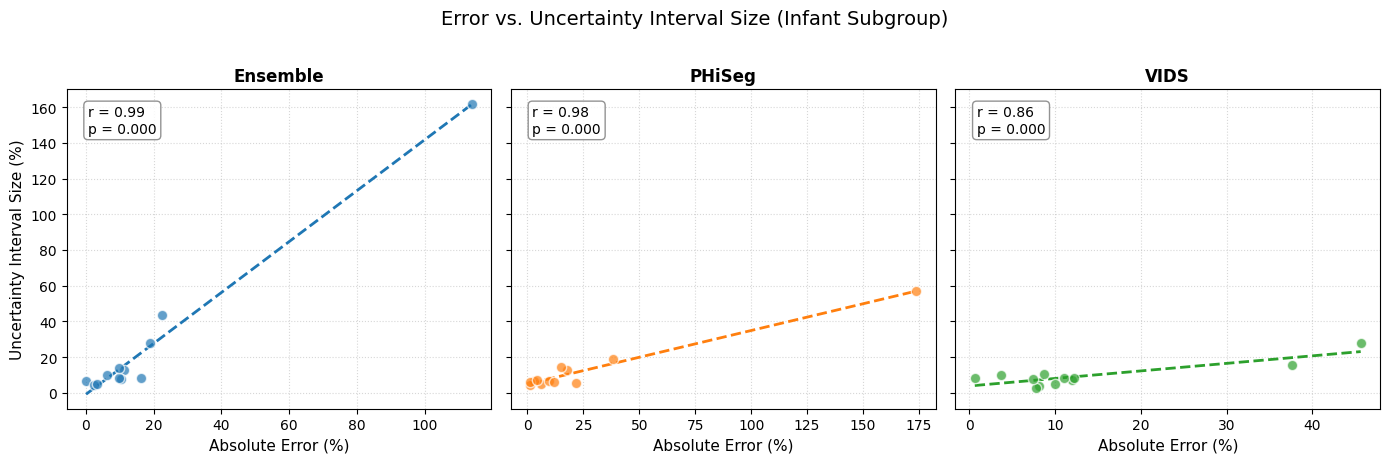

In [6]:
# import matplotlib.pyplot as plt
# import numpy as np
from scipy.stats import pearsonr

# Prepare data
dfs = {'Ensemble': df_ef_ens, 'PHiSeg': df_ef_phiseg, 'VIDS': df_ef_vids}
colors = {'Ensemble': '#1f77b4', 'PHiSeg': '#ff7f0e', 'VIDS': '#2ca02c'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, (name, df) in zip(axes, dfs.items()):
    # Filter infants and drop missing values
    infant = df[df['age_group'] == 'infant'].dropna(subset=['abs_error', 'interval_size'])
    # infant = df[df['age_group'] == 'children'].dropna(subset=['abs_error', 'interval_size'])
    x = infant['abs_error'].values
    y = infant['interval_size'].values
    
    # Scatter plot
    ax.scatter(x, y, color=colors[name], alpha=0.7, edgecolor='white', s=55, zorder=3)
    
    # Pearson correlation & best-fit line
    r, p = pearsonr(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    ax.plot(np.sort(x), slope * np.sort(x) + intercept, 
            color=colors[name], linewidth=2, linestyle='--', zorder=2)
    
    # Annotate correlation
    ax.text(0.05, 0.95, f'r = {r:.2f}\np = {p:.3f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray'))
    
    ax.set_xlabel('Absolute Error (%)', fontsize=11)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.5)

axes[0].set_ylabel('Uncertainty Interval Size (%)', fontsize=11)
fig.suptitle('Error vs. Uncertainty Interval Size (Infant Subgroup)', fontsize=14, y=1.02)
fig.tight_layout()

# plt.savefig('ef_error_vs_uncertainty_infant.pdf', dpi=300, bbox_inches='tight')
plt.show()